# Computer Vision Assignment 2 - B00150982


In [13]:
from __future__ import print_function

from tensorflow import keras 
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, BatchNormalization 
from keras.optimizers import RMSprop,Adam 
import matplotlib.pyplot as plt
import numpy as np

In [14]:
batch_size = 12
num_classes = 3
epochs = 8
img_width = 128
img_height = 128
img_channels = 3
fit = True

train_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/train"
test_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/test"

## Dataset balance

In [ ]:
bacterial_count = len(os.listdir(train_dir + "/BACTERIAL"))
normal_count = len(os.listdir(train_dir + "/NORMAL"))
viral_count = len(os.listdir(train_dir + "/VIRAL"))

print("Dataset distribution:")
print("BACTERIAL:", bacterial_count)
print("NORMAL:", normal_count)
print("VIRAL:", viral_count)

total = bacterial_count + normal_count + viral_count
print("Total images:", total)

Dataset distribution:
BACTERIAL: 2596
NORMAL: 1461
VIRAL: 1363
Total images: 5420


## Load dataset

In [16]:
train_ds,val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir,
        seed=123,
        validation_split=0.2,
        subset='both',
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=True
)
    
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        seed=None,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=True
)

class_names = train_ds.class_names
print('Class Names: ',class_names)
num_classes = len(class_names)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class Names:  ['BACTERIAL', 'NORMAL', 'VIRAL']


## Visualise images

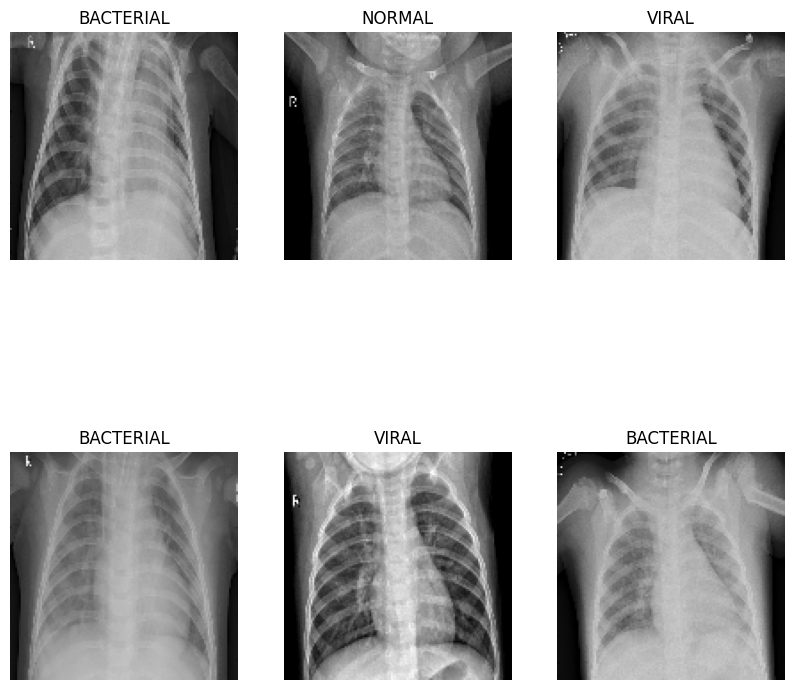

In [17]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()

In [22]:
#create model
model = tf.keras.models.Sequential([
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation = 'relu', input_shape = (img_height,img_width, img_channels)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(), # flatten multidimensional outputs into single dimension for input to dense fully connected layers
    Dense(512, activation = 'relu'),
    Dropout(0.2),
    Dense(num_classes, activation = 'softmax')
])

In [30]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
save_callback = tf.keras.callbacks.ModelCheckpoint(
    "pneumonia.keras",
    save_best_only=True
)

## Train model

In [ ]:
history = model.fit(
        train_ds,
        batch_size=batch_size,
        validation_data=val_ds,
        callbacks=[save_callback],
        epochs=epochs)

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 47s 129ms/step - accuracy: 0.9101 - loss: 0.2135 - val_accuracy: 0.7525 - val_loss: 0.8862
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 46s 126ms/step - accuracy: 0.9329 - loss: 0.1749 - val_accuracy: 0.7581 - val_loss: 1.0055
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 46s 128ms/step - accuracy: 0.9460 - loss: 0.1427 - val_accuracy: 0.7553 - val_loss: 0.9920
Epoch 4/8
 45/362 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.9757 - loss: 0.0687

## Evaluate model

In [33]:
score = model.evaluate(test_ds, batch_size=batch_size)
print('Test accuracy:', score[1])

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7757 - loss: 0.6822
Test accuracy: 0.7757437229156494


## Plot accuracy

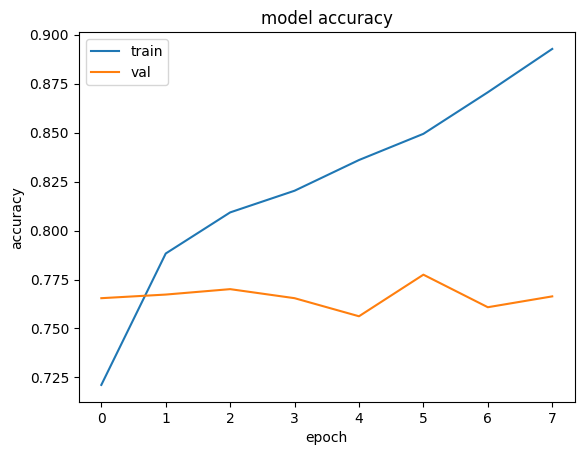

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

## Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


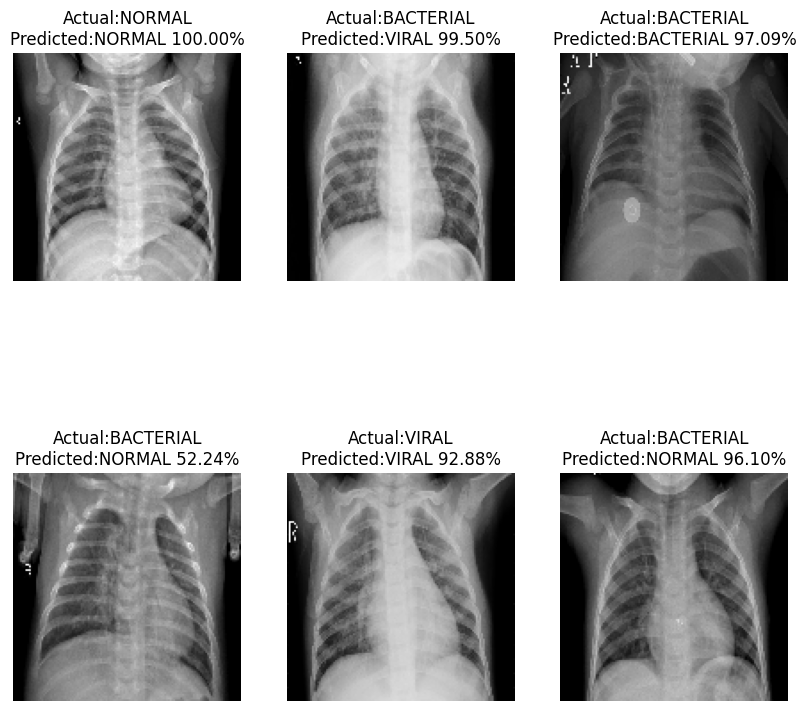

In [35]:
test_batch = test_ds.take(1)
plt.figure(figsize=(10, 10))
for images, labels in test_batch:
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        prediction = model.predict(tf.expand_dims(images[i].numpy(),0))#perform a prediction on this image
        plt.title('Actual:' + class_names[labels[i].numpy()]+ '\nPredicted:{} {:.2f}%'.format(class_names[np.argmax(prediction)], 100 * np.max(prediction)))
        plt.axis("off")
    plt.show()